In [145]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

d = 11
# log target density
def log_target(x):
    return -0.5 * np.sum(x**2)  # N(0,I_d)

In [146]:
sigma = 0.8

def metropolis_kernel(x):
    u = np.random.rand()
    prop = x + sigma * np.random.randn(d)
    if np.log(u) < log_target(prop) - log_target(x):
        return {'val':prop, 'acc':1}
    else:
        return {'val':x, 'acc':0}

In [147]:
N = 10_000  # length of the Markov chain 
s = 0  # nr of times proposed value is accepted
chain = np.empty((N, d))
chain[0, :] = np.linspace(-50, 50, d)
for n in range(1, N):
    output = metropolis_kernel(chain[n-1, :])
    chain[n, :] = output['val']
    s += output['acc']

acc_rate = s / N
print(f'Acceptance rate: {acc_rate}')

Acceptance rate: 0.2245


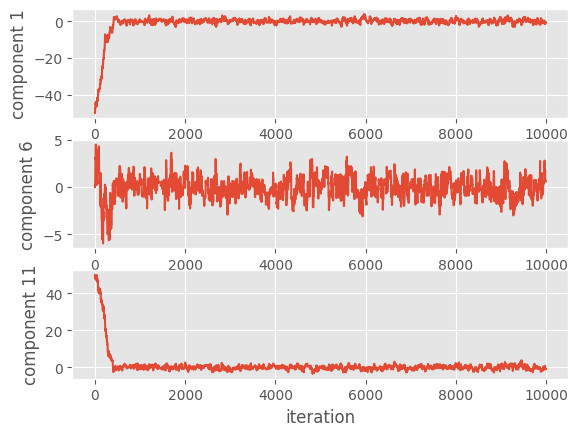

In [151]:
plt.style.use('ggplot')

# Trace plots (first, middle, and last components)
plotted_js = [0, 5, 10]
njs = len(plotted_js)
fig, axes = plt.subplots(njs)
for i, j in enumerate(plotted_js):
    axes[i].plot(chain[:, j])
    axes[i].set_xlabel('iteration')
    axes[i].set_ylabel(f'component {j+1}');

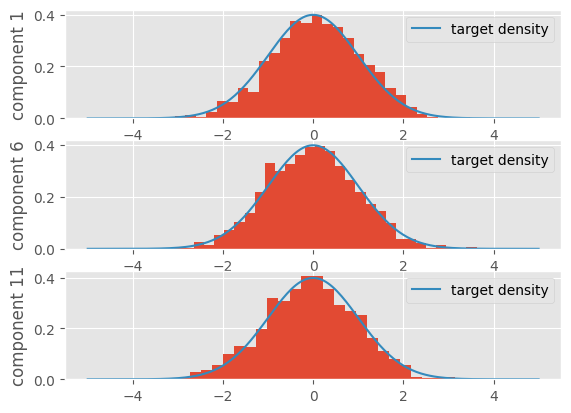

In [156]:
# Histograms

burnin = 1_000  # chosen according to the trace plots

fig, axes = plt.subplots(njs)
for i, j in enumerate(plotted_js):
    axes[i].hist(chain[burnin:, j], 30, density=True)
    xx = np.linspace(-5, 5, 200)
    axes[i].plot(xx, stats.norm.pdf(xx), label='target density')
    axes[i].set_ylabel(f'component {j+1}')
    axes[i].legend()

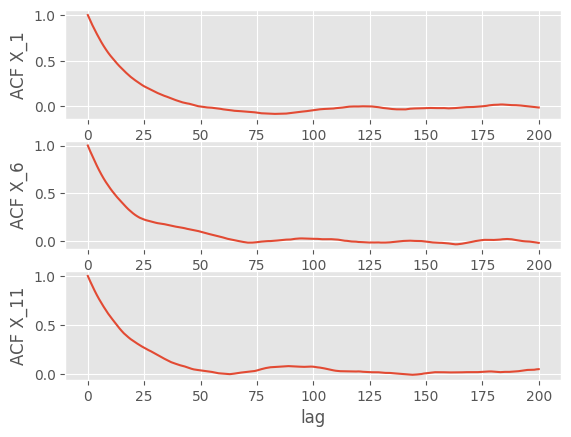

In [157]:
# ACFs 
import statsmodels.api as sm

fig, axes = plt.subplots(njs)
for i, j in enumerate(plotted_js):
    corr = sm.tsa.acf(chain[burnin:, j], nlags=200)
    axes[i].plot(corr)
    axes[i].set_xlabel('lag')
    axes[i].set_ylabel(f'ACF X_{j+1}')